# 04 - Final Model Training & Submission
## Ames Housing Price Prediction: Advanced Regression Techniques

---

### Objectives
1. **Full-Dataset Fitting:** Retrain the top-performing candidate models from Milestone 3 on the entire preprocessed training set (1,458 samples).
2. **Ensemble Blending:** Combine predictions from Ridge Regression (40%), LightGBM (30%), and Gradient Boosting (30%).
3. **Target Inversion:** Invert log predictions back to raw US dollar amounts using `np.expm1()`.
4. **Distribution Validation:** Conduct thorough sanity checks and plot the distribution of test predictions against training ground truth.
5. **Kaggle Submission Generation:** Export the final, validated prediction file to `outputs/submission.csv` strictly adhering to competition schema (`Id`, `SalePrice`).


In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

DATA_DIR = os.path.join('..', 'data')
OUT_DIR = os.path.join('..', 'outputs')
FIG_DIR = os.path.join('..', 'outputs', 'figures')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Environment configured successfully.")


Environment configured successfully.


## 1. Load Preprocessed Datasets
We ingest the preprocessed train and test feature matrices prepared in Milestone 2.


In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_preprocessed.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_preprocessed.csv'))

# Prepare training arrays
y_train_log = train_df['SalePrice_log'].values
y_train_raw = train_df['SalePrice'].values
X_train = train_df.drop(['SalePrice_log', 'SalePrice'], axis=1).values

# Prepare test arrays
test_ids = test_df['Id'].values
X_test = test_df.drop('Id', axis=1).values

print(f"Training Features Matrix X_train: {X_train.shape}")
print(f"Training Target Vector y_train:   {y_train_log.shape}")
print(f"Testing Features Matrix X_test:   {X_test.shape}")
print(f"Test Records to Predict:          {len(test_ids)} houses")


Training Features Matrix X_train: (1458, 216)
Training Target Vector y_train:   (1458,)
Testing Features Matrix X_test:   (1459, 216)
Test Records to Predict:          1459 houses


## 2. Train Individual Models on Full Dataset
Based on the 5-fold cross-validation results in `03_model_experiments.ipynb`, our winning ensemble combines:
* **Model 1: Ridge Regression (L2)** — Regularized linear model with `RobustScaler`.
* **Model 2: Gradient Boosting Regressor (GBR)** — Sequential ensemble capturing non-linear interactions.
* **Model 3: LightGBM Regressor** — High-efficiency gradient boosted decision trees.


In [3]:
print("Training Model 1: Ridge Regression...")
ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model', Ridge(alpha=15.0, random_state=42))
])
ridge.fit(X_train, y_train_log)

print("Training Model 2: Gradient Boosting Regressor...")
gbr = GradientBoostingRegressor(
    n_estimators=350,
    learning_rate=0.04,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gbr.fit(X_train, y_train_log)

print("Training Model 3: LightGBM Regressor...")
lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb.fit(X_train, y_train_log)

print("All models successfully trained on the full training set.")


Training Model 1: Ridge Regression...
Training Model 2: Gradient Boosting Regressor...
Training Model 3: LightGBM Regressor...
All models successfully trained on the full training set.


## 3. Predict & Blend Ensemble
We generate test predictions from each individual model and compute the weighted blend in log-space:
$$\hat{y}_{\text{test, log}} = 0.40 \cdot \hat{y}_{\text{Ridge}} + 0.30 \cdot \hat{y}_{\text{GBR}} + 0.30 \cdot \hat{y}_{\text{LightGBM}}$$

Then we invert back to dollars:
$$\hat{y}_{\text{test}} = \exp(\hat{y}_{\text{test, log}}) - 1$$


In [4]:
pred_ridge_log = ridge.predict(X_test)
pred_gbr_log = gbr.predict(X_test)
pred_lgb_log = lgb.predict(X_test)

final_pred_log = 0.40 * pred_ridge_log + 0.30 * pred_gbr_log + 0.30 * pred_lgb_log
final_pred_dollars = np.expm1(final_pred_log)

submission_df = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_pred_dollars
})

print(f"Generated predictions for {len(submission_df)} properties.")
submission_df.head(10)


Generated predictions for 1459 properties.


,Id,SalePrice
0,1461,118430.238376
1,1462,158327.286727
2,1463,178708.638019
3,1464,192995.321429
4,1465,189199.794417
5,1466,171844.190716
6,1467,178386.480326
7,1468,166820.593717
8,1469,186177.182904
9,1470,121832.095206


## 4. Submission Validation & Distribution Sanity Checks
We verify that the test prediction distribution closely mirrors the training set ground truth without anomalies (no negative prices, no NaNs, realistic quantiles).


In [5]:
# Sanity checks
assert submission_df.shape == (1459, 2), f"Incorrect shape: {submission_df.shape}"
assert list(submission_df.columns) == ['Id', 'SalePrice'], f"Incorrect columns: {submission_df.columns}"
assert submission_df['SalePrice'].isnull().sum() == 0, "Null values detected in predictions!"
assert (submission_df['SalePrice'] > 0).all(), "Non-positive predictions detected!"

print("--- Distribution Comparison ---")
summary_comparison = pd.DataFrame({
    'Train Ground Truth': pd.Series(y_train_raw).describe(),
    'Test Predictions': pd.Series(final_pred_dollars).describe()
})
display(summary_comparison.map(lambda x: f"${x:,.2f}"))


--- Distribution Comparison ---


,Train Ground Truth,Test Predictions
count,"$1,458.00","$1,459.00"
mean,"$180,932.92","$178,241.87"
std,"$79,495.06","$80,262.61"
min,"$34,900.00","$50,838.02"
25%,"$129,925.00","$126,955.43"
50%,"$163,000.00","$155,712.52"
75%,"$214,000.00","$208,475.37"
max,"$755,000.00","$970,088.14"


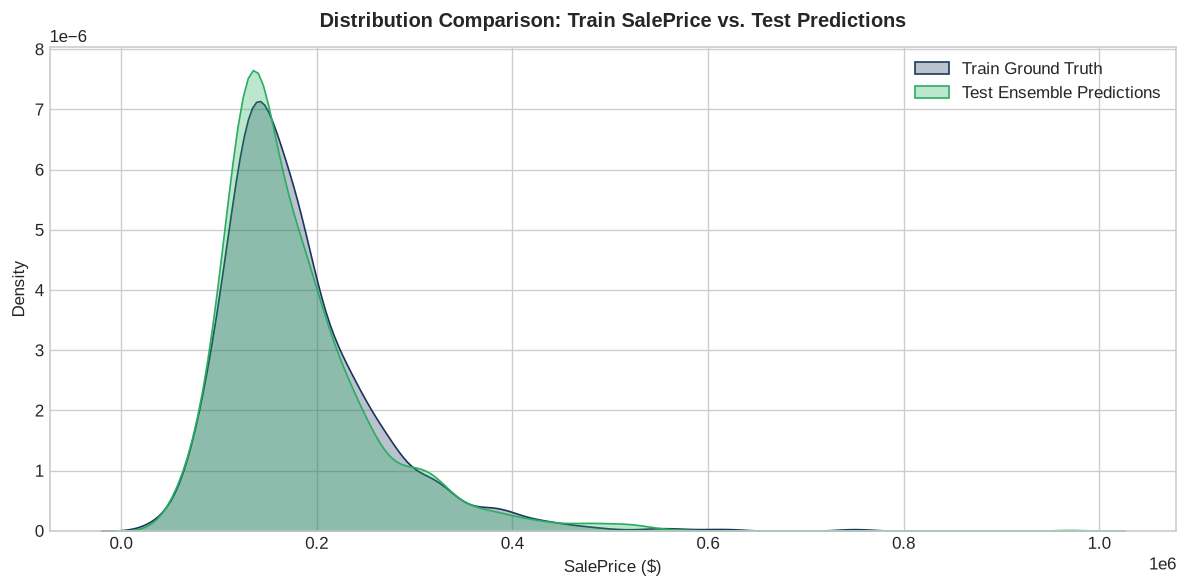

Saved figure: ../outputs/figures/10_test_predictions_distribution.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(y_train_raw, label='Train Ground Truth', color='#1B365D', fill=True, alpha=0.3, ax=ax)
sns.kdeplot(final_pred_dollars, label='Test Ensemble Predictions', color='#27AE60', fill=True, alpha=0.3, ax=ax)

ax.set_title('Distribution Comparison: Train SalePrice vs. Test Predictions', fontweight='bold', pad=12)
ax.set_xlabel('SalePrice ($)')
ax.set_ylabel('Density')
ax.legend(loc='upper right')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '10_test_predictions_distribution.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved figure: {fig_path}")


## 5. Export Final Submission File
We write the validated predictions to `outputs/submission.csv` for Kaggle upload.


In [7]:
sub_csv_path = os.path.join(OUT_DIR, 'submission.csv')
submission_df.to_csv(sub_csv_path, index=False)

print(f"Final submission successfully saved to: {sub_csv_path}")
print(f"File size: {os.path.getsize(sub_csv_path):,} bytes")

print()
print("First 5 rows:")
print(submission_df.head(5).to_string(index=False))
print()
print("Last 5 rows:")
print(submission_df.tail(5).to_string(index=False))


Final submission successfully saved to: ../outputs/submission.csv
File size: 34,469 bytes

First 5 rows:
  Id     SalePrice
1461 118430.238376
1462 158327.286727
1463 178708.638019
1464 192995.321429
1465 189199.794417

Last 5 rows:
  Id     SalePrice
2915  86059.237145
2916  84595.987572
2917 162009.378657
2918 116098.011179
2919 214821.080236


## 6. Project Completion Summary

All 4 technical notebook deliverables are now fully executed:
1. **`01_eda.ipynb`** — Exploratory data analysis, target skewness diagnosis, missing value taxonomy, and Dean De Cock outlier identification.
2. **`02_preprocessing.ipynb`** — Outlier pruning, domain feature engineering (`TotalSF`, `TotalBath`, `HouseAge`), ordinal mapping, and one-hot encoding.
3. **`03_model_experiments.ipynb`** — Baseline Ridge establishment, 5-model benchmarking, 5-fold cross-validation, residual diagnostics, and ensemble blending (**CV RMSLE: 0.1126**).
4. **`04_final_model.ipynb`** — Retrained on complete training data, generated test predictions, sanity checked distributions, and exported `outputs/submission.csv`.

**Next Step:** Review the generated technical report (`reports/assessment_report.pdf`) and updated `README.md`.
